In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import transforms as T

import pytorch_lightning as pl

from torchmetrics.classification import Accuracy
from torchmetrics.aggregation import MeanMetric
from torchvision.datasets import MNIST

from datetime import datetime


from xaikd import datasets, utils, attributors

from tqdm.notebook import tqdm
from xaikd.bases import PRCAReconGreedy, PRCASignAlignGreedy, PRCASignAlignGreedyV2


from zennit.attribution import Gradient
from zennit.composites import EpsilonGammaBox

from xaikd.bases import pcalookahead



import numpy as np
import numpy.typing as npt

import os

In [2]:
!nproc

16


In [3]:
DEVICE = utils.get_device()
DEVICE

'cuda'

In [4]:
NUM_WORKERS = 16

DATA_SIZE = 0.5


In [5]:
ds_train = datasets.MultiTaskEMNISTFashionMNIST(
    train=True,
    root="../../datasets",
    transform=T.Compose(
        [
            T.ToTensor(),
            T.Normalize(
                0.5,
                0.5,
            ),
        ]
    )
)

ds_val = datasets.MultiTaskEMNISTFashionMNIST(
    train=False,
    root="../../datasets",
    transform=T.Compose(
        [
            T.ToTensor(),
            T.Normalize(
                0.5,
                0.5,
            ),
        ]
    )
)

In [6]:
TASK_NUM_CLASSES = ds_train.num_classes

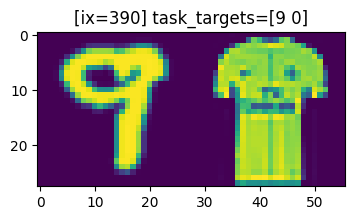

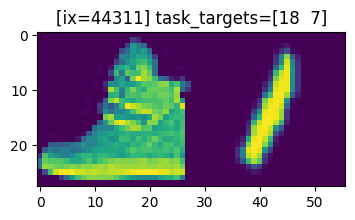

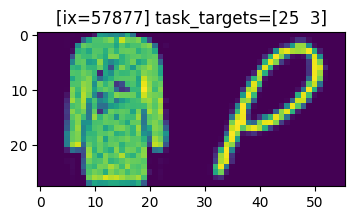

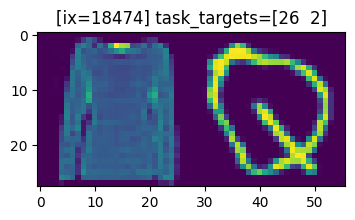

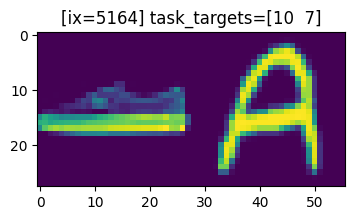

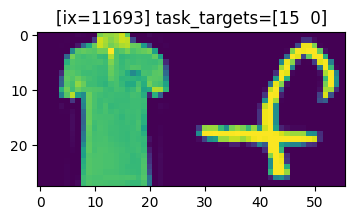

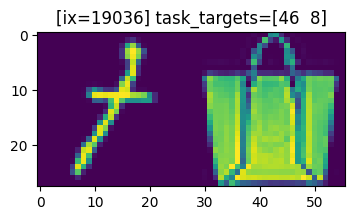

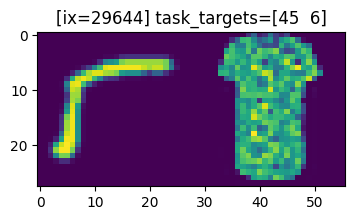

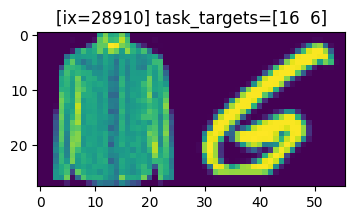

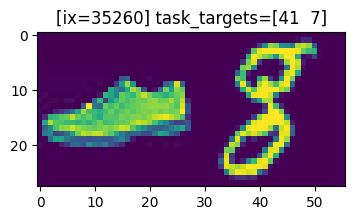

In [7]:
def ano():

    for ix in np.random.permutation(60000)[:10]:
        
        x, y = ds_train[ix]
    
        plt.figure(figsize=(2*2, 2))
        plt.imshow(x.squeeze())
        plt.title(f"[ix={ix}] task_targets={y}")
ano()

# Construct Model and Train

In [13]:
class CNN(nn.Module):
    def __init__(self, num_classes=10, d=256):
        super().__init__()
        self.conv1 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=1)
        self.act1 = nn.ReLU()
        self.max1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=d)
        self.act2 = nn.ReLU()
        self.max2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=d)
        self.act3 = nn.ReLU()
        self.avgpool = nn.AdaptiveAvgPool2d(output_size=1)
        
        self.fc_task_1 = nn.Linear(d, TASK_NUM_CLASSES[0])
        self.fc_task_2 = nn.Linear(d, TASK_NUM_CLASSES[1])

    def forward(self, x):
        x = self.act1(self.conv1(x))
        x = self.max1(x)
        
        x = self.act2(self.conv2(x))
        x = self.max2(x)
        
        x = self.act3(self.conv3(x))
        
        x = self.avgpool(x)
        x = torch.flatten(x, start_dim=1)
        out_task_1 = self.fc_task_1(x)
        out_task_2 = self.fc_task_2(x)

        return out_task_1, out_task_2
    
def ano():
    
    out = CNN()(torch.randn(7, 1, 28, 28*2))
    
    print(f"santity check")
ano()

santity check


In [14]:
from torchvision.models.resnet import resnet18
from torch import nn

In [15]:
resnet18(num_classes=10);

In [16]:
class ModelWrapper(pl.LightningModule):
    def __init__(self, encoder, lr=1e-3, weight_decay=0.0):
        super().__init__()

        self.encoder = encoder
        
        self.weight_decay = weight_decay
        self.lr = lr

    def forward(self, x):
        embedding = self.encoder(x)
        return embedding

    def configure_optimizers(self):

        optimizer = torch.optim.Adam(
            self.parameters(), lr=self.lr, 
            # momentum=0.0, weight_decay=self.weight_decay
        )

        return optimizer

    def compute_metric(self, batch, prefix):

        x, y = batch

        arr_logits = self.encoder(x)

        loss = 0
        for tidx in range(2):
            y_task = y[:, tidx]
            logits_task = arr_logits[tidx]
            loss += 0.5*F.cross_entropy(
                logits_task, 
                y_task
            )

        return loss

    def training_step(self, train_batch, batch_idx):

        loss = self.compute_metric(train_batch, "train")

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def summary_metric(self, prefix):

        metric = self.metrics[prefix]
        value = metric.compute()

        self.log(f"{prefix}_acc", value)

        metric.reset()

In [17]:
pl.seed_everything(1)


dl_train_noshuffle = DataLoader(
    random_split(ds_train, [DATA_SIZE, 1-DATA_SIZE])[0],
    batch_size=64,
    num_workers=NUM_WORKERS,
    # pin_memory=True,
    shuffle=False,
)

dl_test = DataLoader(
    ds_val,
    batch_size=64,
    num_workers=NUM_WORKERS,
    # pin_memory=True,
    shuffle=False,
)

dl_train = DataLoader(
    ds_train,
    batch_size=64,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)


model  = CNN()

trainer = pl.Trainer(
    max_epochs=50,
    accelerator=DEVICE,
    default_root_dir="/tmp"
)

# trainer.fit(ModelWrapper(model), dl_train, dl_test)
# torch.save(model.state_dict(), "./model-cnn-multinist.pth")

model.load_state_dict(
    torch.load("./model-cnn-multinist.pth")
)
model = model.to(DEVICE)

model.eval()

[rank: 0] Global seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


CNN(
  (conv1): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1))
  (act1): ReLU()
  (max1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act2): ReLU()
  (max2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act3): ReLU()
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (fc_task_1): Linear(in_features=256, out_features=47, bias=True)
  (fc_task_2): Linear(in_features=256, out_features=10, bias=True)
)

In [18]:
def estimate_task_acc(model, dl, task_id, verbose=False):
    metric = Accuracy(task="multiclass", num_classes=TASK_NUM_CLASSES[task_id])
    metric_xent = MeanMetric()
    for x, y in tqdm(dl, disable=not verbose):
        task_logit = model(x.to(DEVICE))[task_id].detach().cpu()
        task_target = y[:, task_id]
        metric.update(task_logit, task_target)
        metric_xent.update(F.cross_entropy(task_logit, task_target))
    acc =  float(metric.compute())
    xent = float(metric_xent.compute())
    return acc, xent
def compute_accs():
    
    stats = dict()
    
    for tidx in tqdm(range(2)):
        
        for label, dl in [
            # ("train", dl_train_noshuffle),
            ("test", dl_test)
        ]:            
            stats[f"acc_task_{tidx}_{label}"], stats[f"xent_task_{tidx}_{label}"] = estimate_task_acc(model, dl, tidx)
    
    return stats

ref_stats = compute_accs()
ref_stats

  0%|          | 0/2 [00:00<?, ?it/s]

{'acc_task_0_test': 0.8428000211715698,
 'xent_task_0_test': 0.5066717267036438,
 'acc_task_1_test': 0.8921999931335449,
 'xent_task_1_test': 0.33956974744796753}

# LRP Checking

In [19]:
GAMMA = 0.01

sanity_check: passed


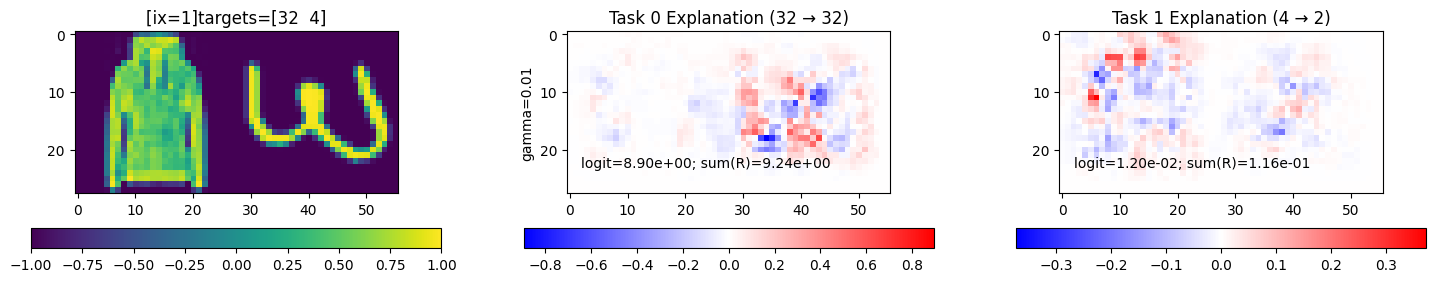

In [21]:


class TaskSpecificHeadModel(nn.Module):
    def __init__(self, model, task_id: int):
        super().__init__()
        self.model = model
        self.task_id = task_id 

    def forward(self, x):
        return self.model(x)[self.task_id]

def make_attributor(model):
    
    low = torch.tensor([-1.])
    high = torch.tensor([1.])

    composite = EpsilonGammaBox(low=low, high=high, gamma=GAMMA)

    return Gradient(model=model, composite=composite)


def sanity_check():

    task_id = 0

    logit_modifier = attributors.WinningClassEvidence(num_classes=TASK_NUM_CLASSES[task_id])
    task_specific_model = TaskSpecificHeadModel(model, task_id=task_id)
    with make_attributor(task_specific_model) as attributor:
        x = torch.randn((7, 1, 28, 28*2)).to(DEVICE)
        
        _ = attributor.forward(x, lambda logits: logit_modifier(logits, None))
    print("sanity_check: passed")

sanity_check()

def viz_explain_tasks(sample_ix):

    ncols = 3
    plt.figure(figsize=(6*ncols, 3))

    x, y = ds_val[sample_ix]
    x = x.unsqueeze(0).to(DEVICE)

    plt.subplot(1, 3, 1)
    plt.title(f"[ix={sample_ix}]targets={y}")

    plt.imshow(x.detach().cpu().numpy().squeeze())
    plt.colorbar(location="bottom")
    for task_id in [0, 1]:
        task_specific_model = TaskSpecificHeadModel(model, task_id=task_id)
        
        with make_attributor(task_specific_model) as attributor:

            task_logits, heatmap = attributor.forward(
                x, 
                lambda logits: logits * F.one_hot(torch.tensor([y[task_id]]), num_classes=TASK_NUM_CLASSES[task_id]).to(logits.device)
            )

            task_logits = task_logits.detach().cpu().numpy()
            pred = np.argmax(task_logits)

            plt.subplot(1, ncols, task_id + 2)

            plt.title(f"Task {task_id} Explanation ({y[task_id]} → {pred})")
            if task_id == 0:
                plt.ylabel(f"gamma={GAMMA}")
            heatmap = heatmap.cpu().detach().numpy().squeeze()
            plt.text(2, 28-5, f"logit={task_logits[0, y[task_id]]:.2e}; sum(R)={heatmap.sum():.2e}")
            vmax = np.abs(heatmap).max()
            plt.imshow(heatmap, cmap="bwr", vmin=-vmax, vmax=vmax)
            plt.colorbar(location="bottom")
    
viz_explain_tasks(1)

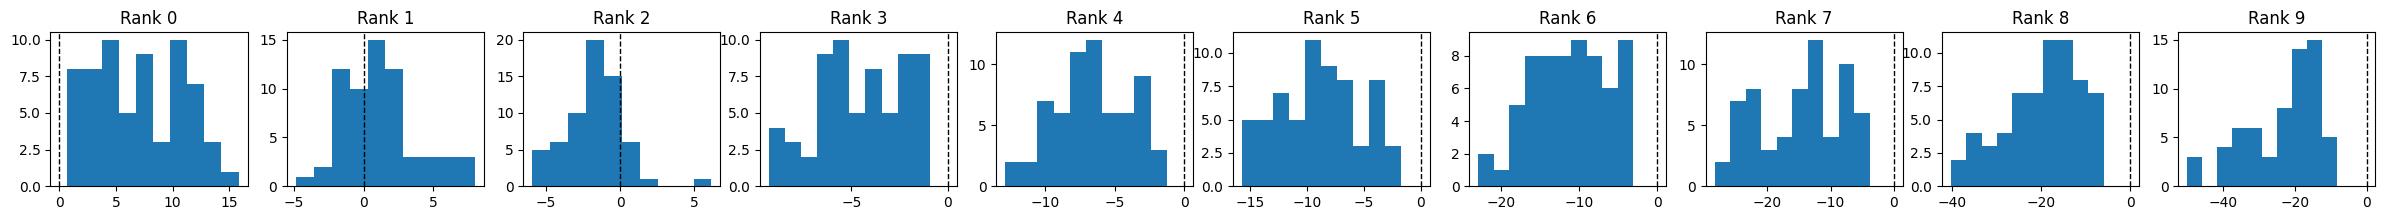

In [22]:
@torch.no_grad()
def check_winning_logits():

    ncols = 10
    task_id = 1
    plt.figure(figsize=(ncols*3, 2))
    for rank_ix in range(ncols):
        plt.subplot(1, ncols, rank_ix + 1)
        plt.title(f"Rank {rank_ix}")
        arr_winning_logits = []
        
        for x, _ in dl_train_noshuffle:
            logits = model(x.to(DEVICE))[task_id].detach().cpu()
            _, nc = logits.shape
            
            _, indices = torch.topk(logits, dim=1, k=ncols)
            one_hot = F.one_hot(
                indices[:, rank_ix], 
                num_classes=nc
            )
    
            rank_logits = (one_hot * logits).sum(dim=1)
            
            arr_winning_logits.extend(rank_logits.numpy().tolist())
    
            break
        plt.axvline(0, ls="--", lw=1, color="k")
        plt.hist(arr_winning_logits)
check_winning_logits()

# Extract Act and Ctx

In [23]:
ARR_LAYERS = ["max1", "max2", "act3"]

ARR_LAYERS

['max1', 'max2', 'act3']

In [24]:
model

CNN(
  (conv1): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1))
  (act1): ReLU()
  (max1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act2): ReLU()
  (max2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act3): ReLU()
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (fc_task_1): Linear(in_features=256, out_features=47, bias=True)
  (fc_task_2): Linear(in_features=256, out_features=10, bias=True)
)

In [25]:
from collections import OrderedDict

In [26]:
def split_model_for_task(model, layer, task_id):

    arr_name_layers = list(model.named_children())

    layer_names = list(map(lambda t: t[0], arr_name_layers))
    layer_ix = layer_names.index(layer)
    avgpool_ix = layer_names.index("avgpool")


    task_module_name = f"fc_task_{task_id+1}"
    
    task_module = getattr(model, task_module_name)

    first_module = nn.Sequential(OrderedDict(
        arr_name_layers[:layer_ix+1]
    ))
    second_module = nn.Sequential(OrderedDict(
        arr_name_layers[layer_ix+1:avgpool_ix+1] 
        + [
            ("flatten", nn.Flatten(start_dim=1)),
            (task_module_name, task_module)
        ]
    ))
    
    return first_module, second_module

@torch.no_grad()
def ano():


    trng = torch.Generator()
    trng.manual_seed(1)
    
    x = torch.randn(10, 1, 28, 56, generator=trng).to(DEVICE)
    
        
    for task_id in [0, 1]:
        for layer in ARR_LAYERS:
            m1, m2 = split_model_for_task(model, layer, task_id)

            actual = m2(m1(x)).cpu().numpy()
            expected = model(x)[task_id].cpu().numpy()
            np.testing.assert_allclose(
                actual,
                expected
            )
            print(f"sanity check: task_id={task_id} layer={layer} passed!")
ano()

sanity check: task_id=0 layer=max1 passed!
sanity check: task_id=0 layer=max2 passed!
sanity check: task_id=0 layer=act3 passed!
sanity check: task_id=1 layer=max1 passed!
sanity check: task_id=1 layer=max2 passed!
sanity check: task_id=1 layer=act3 passed!


In [104]:
class OutputQuantity:
    def __call__(self, logits, target_logits):
        raise NotImplementedError()
    def __str__(self):
        return self.__class__.__name__


def compute_log_odd_winning(logits: torch.Tensor) -> torch.Tensor:

    ns, nc = logits.shape

    values, _ = torch.topk(logits, dim=1, k=nc)

    logit_winning = values[:, 0]
    lse_others = torch.logsumexp(values[:, 1:], dim=1)
    log_odd = logit_winning - lse_others

    return log_odd

        
class LogOddWinningClass(OutputQuantity):
    def __call__(self, logits, targets):
        return torch.sign(logits).detach() * logits
        return compute_log_odd_winning(logits)


        
class CrossEntropyOutput(OutputQuantity):
    def __call__(self, logits, targets):

        y_pred = torch.argmax(logits, dim=1)
        loss = F.cross_entropy(logits, y_pred, reduce="none")

        # convert to maximization problem
        loss = - loss
        return loss

In [105]:
class VoidAttributor:

    def __enter__(self, **kwargs):
        pass

    def __exit__(self, type, value, tb):
        pass
        
def extract_activation_context(
    model: nn.Module,
    layer: str,
    data_loader: DataLoader,
    task_id: int,
    output_quantity: OutputQuantity,
    rng: np.random.Generator,
    use_lrp: bool,
    device="cpu",
    number_of_selected_spatial_locations=20,
    strict_mode=False,
    verbose=False,
):
    arr_act = []
    arr_ctx = []

    num_classes = TASK_NUM_CLASSES[task_id]

    try:
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

        task_specific_head = TaskSpecificHeadModel(model, task_id=task_id)

        
        attributor = make_attributor(task_specific_head) if use_lrp else VoidAttributor()
        
        with attributor:
            for batch in tqdm(data_loader, desc=f"extract act ctx (use_lrp={use_lrp}; output_quantity={output_quantity.__class__.__name__}) at layer={layer}"):
                x, y = batch
                x = x.to(device)



                if use_lrp:
                    _ = attributor.forward(x, lambda logits: logit_mod(logits, y))

                    act = utils.interceptor.get_output(module)
                    assert act.grad is not None

                    rel = act.grad
    
                    output_dimensions = act.shape[1:]
    
                    ctx = torch.where(act.abs() > 0, rel / act, 0)
    
                    if strict_mode:
                        np.testing.assert_allclose(
                            (act * ctx).detach().cpu().numpy(),
                            rel.detach().cpu().numpy(),
                            atol=1e-6,
                        )

                else:
                    
                    logits = task_specific_head(x)
                    (output_quantity(logits, y)).sum().backward()
                    act = utils.interceptor.get_output(module)
                    output_dimensions = act.shape[1:]

                    assert act.grad is not None
                    ctx = act.grad

                assert ctx.shape == act.shape

                
                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

    finally:
        hook.remove()

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx


def extract_act_grad(model, layer, output_quantity, dl, task_id, use_lrp):
    


    return extract_activation_context(
        model=model,
        layer=layer,
        data_loader=dl_train_noshuffle,
        task_id=task_id,
        output_quantity=output_quantity,
        rng=np.random.default_rng(seed=1),
        device=DEVICE,
        use_lrp=use_lrp
    )

extract_act_grad(model, "max2", CrossEntropyOutput(), dl_train_noshuffle, 0, use_lrp=False)
# extract_act_grad(model, "act3", "winning-0", dl_train_noshuffle, 0, use_lrp=False)

extract act ctx (use_lrp=False; output_quantity=CrossEntropyOutput) at layer=max2:   0%|          | 0/469 [00:…

max2: output-dims=torch.Size([256, 5, 12])


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 array([[ 2.4210177e-11,  6.5743895e-12,  9.4856701e-12, ...,
         -2.5388009e-11,  3.0797587e-12,  3.4890398e-12],
        [-2.8214483e-11, -1.7904164e-11,  2.0542928e-11, ...,
         -1.9981187e-11, -2.5351563e-11, -3.3432895e-11],
        [ 2.8406793e-11,  3.3171493e-11, -1.8122608e-11, ...,
         -3.0830921e-11,  4.9157206e-11,  8.7966232e-11],
        ...,
        [ 2.3374369e-09,  2.3919933e-10, -1.7341648e-09, ...,
          2.2307489e-09,  1.2909247e-09,  2.5352946e-09],
        [-1.1197155e-08,  4.2753676e-09, -1.3119360e-08, ...,
         -2.0464963e-11,  1.4934589e-09,  8.4492466e-09],
        [-4.5452664e-09, -4.3951061e-09, -9.7669850e-10, ...,
          8.9329406e-09, -2.2268050e-09,  1.9578410e-09]], dt

In [106]:
def sanity_check():
    arr_act, _ = extract_act_grad(model, dl_train_noshuffle, 0)
    
    for tidx in [1]:
        arr_act_other, _ = extract_act_grad(model, dl_train_noshuffle, tidx)
        np.testing.assert_allclose(
            arr_act_other,
            arr_act
        )
        print(f"arr_act(T0) == arr_act(T{tidx})")
    print("all passed!")

# sanity_check()

# Basis Construction

In [107]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs

## Baseline

In [108]:

class BasisInterface:
    def get_Uk(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

class PCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_act
        self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class GradPCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_ctx.T @ arr_ctx
        self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCASortAbs(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class PRCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]



class PRCASignAlignSortAbs(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        arr_rel = (arr_act * arr_ctx).sum(axis=1, keepdims=True)
        arr_ctx = (arr_rel >= 0) * arr_ctx - (arr_rel < 0) * arr_ctx
        
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        
        self.U = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

## PCALookAhead

In [109]:
class PCALookAheadBasis(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        self.arr_act = arr_act
        self.arr_ctx = arr_ctx

        self.layer = layer
        self.task_id = task_id
        self.is_slow = True
        
    def get_Uk(self, k: int):
        first_module, second_module = split_model_for_task(
            model,
            layer=self.layer,
            task_id=self.task_id
        ) 

        U = pcalookahead.fit_v2(
            first_module=first_module,
            second_module=second_module,
            dataloader=dl_train,
            Uinit=PCABasis(arr_act=self.arr_act, arr_ctx=self.arr_ctx).get_Uk(k),
            k=k,
            epochs=5,
            verbose=True,
            device=DEVICE
        )
        np.testing.assert_allclose(
            U.T @ U,
            np.eye(k),
            atol=1e-5
        )
        return U

## PRCARecon (non greedy)

In [110]:
class PRCAReconNonGreedyLearner:
    def __init__(self, task_id, layer):
        self.task_id = task_id
        self.layer = layer
    def fit(
        self,  arr_act: npt.NDArray, arr_ctx: npt.NDArray, k: int,  U_init=None, device="cpu",
    ) -> npt.NDArray:
        n, d, = arr_act.shape

        assert arr_ctx.shape == arr_act.shape, arr_ctx.shape
        
        lr = 1e-4
        epochs = 5000
                
        n, d, = arr_act.shape

        scale_act = ((np.mean(arr_act**2) ** (1 / 2)) * (d ** (1 / 4)))
        scale_ctx = ((np.mean(arr_ctx**2) ** (1 / 2)) * (d ** (1 / 4)))
        arr_act = arr_act / scale_act
        arr_ctx = arr_ctx / scale_ctx
        
        arr_act: torch.Tensor = torch.from_numpy(arr_act).to(device)
        arr_ctx: torch.Tensor = torch.from_numpy(arr_ctx).to(device)


        linear_layer = torch.nn.Linear(k, d, bias=False)
        trng = torch.Generator()
        trng.manual_seed(1)
        if U_init is None:
            U_init = torch.randn((k, d), generator=trng)
        else:
            U_init = torch.from_numpy(U_init.T)
            
        linear_layer.weight = torch.nn.Parameter(U_init)
    
        ortho_layer = torch.nn.utils.parametrizations.orthogonal(linear_layer).to(device)
        assert ortho_layer.weight.shape == (k, d)
        
        optimizer = torch.optim.Adam(ortho_layer.parameters(), lr=lr)

        rel = (arr_act*arr_ctx).sum(dim=1)
        
        pgb = tqdm(range(epochs), desc=f"{self.__class__.__name__} (k={k})")
        for epoch in pgb:
            optimizer.zero_grad()
            
            # shape: (k, d)
            U = ortho_layer.weight

            act_proj = (arr_act @ U.T ) @ U

            ctx_proj = (arr_ctx @ U.T) @ U
            
            rel_recon = (act_proj * ctx_proj).sum(dim=1)


            # shape = (n, )
            loss = (rel - rel_recon).pow(2)
    
            loss = loss.mean()
            
            loss.backward()
        
            optimizer.step()

            loss = loss.detach().cpu().numpy()
                
            pgb.set_description_str(f"{self.__class__.__name__} (k={k}; lr={lr}) loss={loss:.4e}")
            
        U =  ortho_layer.weight.T.detach().cpu().numpy()
        
        # sanity_check
        np.testing.assert_allclose(U.T @ U, np.eye(k), atol=1e-4)

        return U


class PRCARecon(BasisInterface):
    def __init__(self,  arr_act, arr_ctx, layer=None, task_id=None):
        self.arr_act = arr_act
        self.arr_ctx = arr_ctx
        self.layer = layer
        self.task_id = task_id
        self.is_slow = True
        
    def get_Uk(self, k: int):

        return PRCAReconNonGreedyLearner(
            layer=self.layer,
            task_id=self.task_id
        ).fit(
            self.arr_act, self.arr_ctx, 
            k=k,
            U_init=PRCASortAbs(arr_act=self.arr_act, arr_ctx=self.arr_ctx).get_Uk(k),
            device=DEVICE
        )

In [126]:
class PRCAReconNormGradNonGreedyLearner:
    def __init__(self, task_id, layer):
        self.task_id = task_id
        self.layer = layer
    def fit(
        self,  arr_act: npt.NDArray, arr_ctx: npt.NDArray, k: int,  U_init=None, device="cpu",
    ) -> npt.NDArray:
        n, d, = arr_act.shape

        assert arr_ctx.shape == arr_act.shape, arr_ctx.shape
        
        lr = 1e-1
        epochs = 5000
                
        n, d, = arr_act.shape

        # scale_act = ((np.mean(arr_act**2) ** (1 / 2)) * (d ** (1 / 4)))
        # scale_ctx = ((np.mean(arr_ctx**2) ** (1 / 2)) * (d ** (1 / 4)))
        
        
        arr_act: torch.Tensor = torch.from_numpy(arr_act).to(device)
        arr_ctx: torch.Tensor = torch.from_numpy(arr_ctx).to(device)
        

        linear_layer = torch.nn.Linear(k, d, bias=False)
        trng = torch.Generator()
        trng.manual_seed(1)
        if U_init is None:
            U_init = torch.randn((k, d), generator=trng)
        else:
            U_init = torch.from_numpy(U_init.T)
            
        linear_layer.weight = torch.nn.Parameter(U_init)
    
        ortho_layer = torch.nn.utils.parametrizations.orthogonal(linear_layer).to(device)
        assert ortho_layer.weight.shape == (k, d)
        
        optimizer = torch.optim.Adam(ortho_layer.parameters(), lr=lr)

        
        pgb = tqdm(range(epochs), desc=f"{self.__class__.__name__} (k={k})")
        for epoch in pgb:
            optimizer.zero_grad()
            
            # shape: (k, d)
            U = ortho_layer.weight

            residue =  arr_act - (arr_act @ U.T ) @ U

            loss = (arr_ctx * residue).sum(axis=1).abs()  / (torch.norm(arr_ctx) + 1e-6)
    
            loss = loss.mean()
            
            loss.backward()
        
            optimizer.step()

            loss = loss.detach().cpu().numpy()
                
            pgb.set_description_str(f"{self.__class__.__name__} (k={k}; lr={lr}) loss={loss:.4e}")
            
        U =  ortho_layer.weight.T.detach().cpu().numpy()
        
        # sanity_check
        np.testing.assert_allclose(U.T @ U, np.eye(k), atol=1e-4)

        return U


class PRCAReconNormGrad(BasisInterface):
    def __init__(self,  arr_act, arr_ctx, layer=None, task_id=None):
        self.arr_act = arr_act
        self.arr_ctx = arr_ctx
        self.layer = layer
        self.task_id = task_id
        self.is_slow = True
        
    def get_Uk(self, k: int):

        return PRCAReconCosineNonGreedyLearner(
            layer=self.layer,
            task_id=self.task_id
        ).fit(
            self.arr_act, self.arr_ctx, 
            k=k,
            U_init=PRCASortAbs(arr_act=self.arr_act, arr_ctx=self.arr_ctx).get_Uk(k),
            device=DEVICE
        )

In [127]:
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            (Uk@Uk.T).unsqueeze(2).unsqueeze(3)
        )
    return fh

def compute_task_acc_at_k(
    model, layer, task_id, 
    arr_ks, arr_ks_for_slow_learners,
    use_lrp=False,
    arr_basis_classes=[PCA],
    base_output_dir="./artifacts/multinist",
):
    output_quantity = LogOddWinningClass()

    arr_act, arr_ctx = extract_act_grad(
        model, 
        layer, 
        dl=dl_train_noshuffle, task_id=task_id, output_quantity=output_quantity, use_lrp=use_lrp)

    arr_ks = sorted(list(set(arr_ks + arr_ks_for_slow_learners)))
    
    module = getattr(model, layer)

    rel = (arr_act  * arr_ctx).sum(axis=1)

    suffix = "relevance-lrp" if use_lrp else "relevance-grad"
    output_path = f"{base_output_dir}/task-{task_id}/{layer}/{suffix}"
    os.makedirs(output_path, exist_ok=True)

    arr_dfs = []

    for basis_class in arr_basis_classes:
        basis: BasisInterface = basis_class(
            arr_act=arr_act, 
            arr_ctx=arr_ctx,
            layer=layer,
            task_id=task_id
        )
        basis_name = basis.__class__.__name__
        arr_stat_rows = []

        for k in tqdm(
            arr_ks_for_slow_learners if hasattr(basis, "is_slow") else arr_ks, 
            desc=f"[{basis_name:<20s}] Estimating Performance"
        ):

            Uk = basis.get_Uk(k=k)

            arr_recon_act = (arr_act @ Uk) @ Uk.T
            residue = arr_act - arr_recon_act
            recon_err = np.linalg.norm(residue, axis=1).mean()
            projected_rel = ((arr_act @ Uk) * (arr_ctx @ Uk)).sum(axis=1)
            rel_recon_err = ((rel - projected_rel) **2).mean()
            assert rel.shape == projected_rel.shape == (rel.shape[0], )
            perc_sign_align = (np.sign(rel) * np.sign(projected_rel)).mean()
            cosine = ( 
                (arr_ctx / (np.linalg.norm(arr_ctx, axis=1, keepdims=True)) + 1e-6) \
                * (residue / (np.linalg.norm(residue, axis=1, keepdims=True)  + 1e-6))
            ).sum(axis=1)
            cosine = np.abs(cosine).mean()
            Uk = torch.from_numpy(Uk).to(DEVICE)
            row = dict(
                layer=layer,
                task_id=task_id, 
                output_quantity=output_quantity.__class__.__name__,
                gamma=GAMMA,
                k=k, 

                basis_name=basis_name,
                recon_err=recon_err,
                cosine=cosine,
                rel_recon_err=rel_recon_err,
                perc_sign_align=perc_sign_align,
            )
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                for label, dl in [
                    ("test", dl_test)
                ]:
                    row[f"acc_{label}"], row[f"xent_{label}"] = estimate_task_acc(model, dl, task_id)
                
            finally:
                hook.remove()
            arr_stat_rows.append(row)
            
        df = pd.DataFrame(arr_stat_rows)
        df.to_csv(
            f"{output_path}/{basis_name}.csv",
            index=False
        )

        arr_dfs.append(df)

    df = pd.concat(arr_dfs).sort_values(by=["k", "acc_test"], ascending=[True, False])
    print(f"Checking results at {output_path}")
    return df


# logit_mod_list = winning-class, pos-winner-neg-others, pos-winner-neg-others-onehot, diff-top2winner, all-classes
    

compute_task_acc_at_k(
    model, layer="act3", 
    task_id=0, 
    arr_ks=[5, 10, 15, 256],
    arr_ks_for_slow_learners=[5, 10, 15],
    base_output_dir="./tmp",
    arr_basis_classes=[ 
        PRCAReconNormGrad,
        # PCA,
        # GradPCA,
        # PRCA,
        PRCASortAbs,
        # PRCARecon
     ]
)

extract act ctx (use_lrp=False; output_quantity=LogOddWinningClass) at layer=act3:   0%|          | 0/469 [00:…

act3: output-dims=torch.Size([256, 3, 10])


[PRCAReconNormGrad   ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

PRCAReconCosineNonGreedyLearner (k=5):   0%|          | 0/5000 [00:00<?, ?it/s]

PRCAReconCosineNonGreedyLearner (k=10):   0%|          | 0/5000 [00:00<?, ?it/s]

PRCAReconCosineNonGreedyLearner (k=15):   0%|          | 0/5000 [00:00<?, ?it/s]

[PRCASortAbs         ] Estimating Performance:   0%|          | 0/4 [00:00<?, ?it/s]

Checking results at ./tmp/task-0/act3/relevance-grad


,layer,task_id,output_quantity,gamma,k,basis_name,recon_err,cosine,rel_recon_err,perc_sign_align,acc_test,xent_test
0,act3,0,LogOddWinningClass,0.01,5,PRCAReconNormGrad,59.875408,0.015793,1.144733e+01,0.798562,0.2540,3.324459
0,act3,0,LogOddWinningClass,0.01,5,PRCASortAbs,59.045685,0.021383,2.329257e+01,0.790855,0.1882,3.475184
1,act3,0,LogOddWinningClass,0.01,10,PRCAReconNormGrad,57.412167,0.009840,2.510917e+00,0.804585,0.5858,1.229350
1,act3,0,LogOddWinningClass,0.01,10,PRCASortAbs,55.310154,0.014609,5.353024e+00,0.794382,0.5856,1.278984
2,act3,0,LogOddWinningClass,0.01,15,PRCAReconNormGrad,55.649975,0.006938,9.815446e-01,0.809875,0.7129,0.843344
2,act3,0,LogOddWinningClass,0.01,15,PRCASortAbs,52.339184,0.012363,3.002057e+00,0.798228,0.7102,0.875010
3,act3,0,LogOddWinningClass,0.01,256,PRCASortAbs,0.000020,0.065598,8.413140e-11,0.833805,0.8427,0.506679


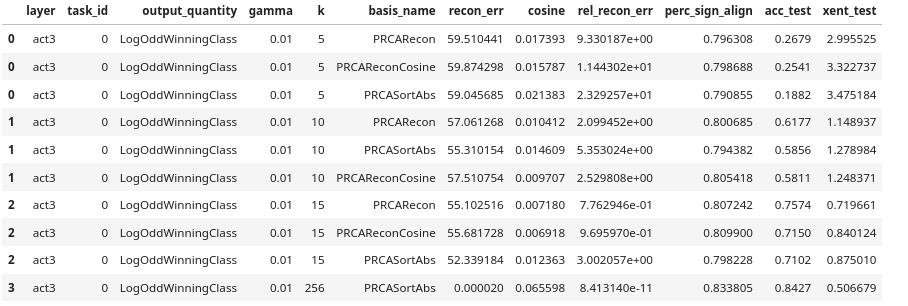

!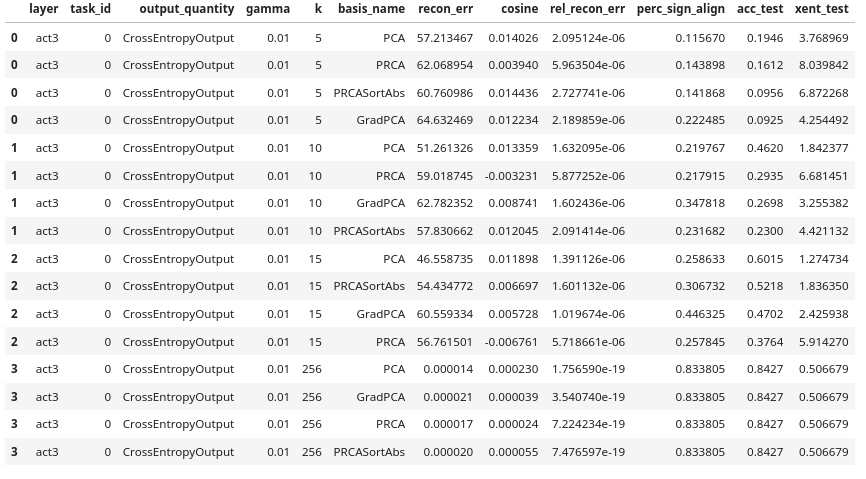

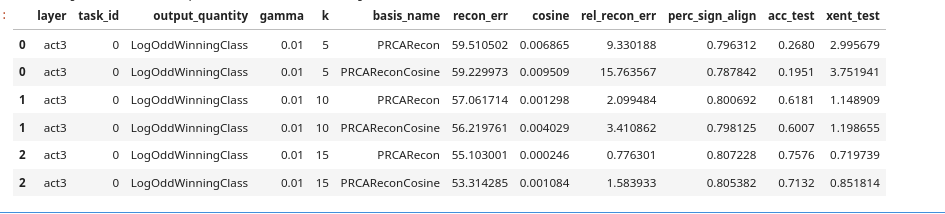

In [86]:
torch.log(1 - torch.sigmoid(torch.Tensor([1.])))

tensor([-1.3133])

In [87]:
compute_log_odd_winning

<function __main__.compute_log_odd_winning(logits: torch.Tensor) -> torch.Tensor>

In [114]:
compute_task_acc_at_k(
    model, layer="max2", 
    task_id=0, 
    arr_ks=[5, 10, 15, 256],
    arr_ks_for_slow_learners=[5, 10, 15],
    base_output_dir="./tmp",
    arr_basis_classes=[ 
        PCA,
        GradPCA,
        PRCA,
        PRCASortAbs,
        PRCARecon
     ]
)

extract act ctx (use_lrp=False; output_quantity=LogOddWinningClass) at layer=max2:   0%|          | 0/469 [00:…

max2: output-dims=torch.Size([256, 5, 12])


[PCA                 ] Estimating Performance:   0%|          | 0/4 [00:00<?, ?it/s]

/tmp/ipykernel_3627306/2321130194.py:60: RuntimeWarning: invalid value encountered in divide
  (arr_ctx / np.linalg.norm(arr_ctx, axis=1, keepdims=True)) \


[GradPCA             ] Estimating Performance:   0%|          | 0/4 [00:00<?, ?it/s]

[PRCA                ] Estimating Performance:   0%|          | 0/4 [00:00<?, ?it/s]

[PRCASortAbs         ] Estimating Performance:   0%|          | 0/4 [00:00<?, ?it/s]

Checking results at ./tmp/task-0/max2/relevance-grad


,layer,task_id,output_quantity,gamma,k,basis_name,recon_err,cosine,rel_recon_err,perc_sign_align,acc_test,xent_test
0,max2,0,LogOddWinningClass,0.01,5,PRCASortAbs,42.694469,NaN,3.885582e+02,0.460495,0.5033,1.821836
0,max2,0,LogOddWinningClass,0.01,5,PCA,36.572441,NaN,8.917028e+02,0.376255,0.3762,2.228623
0,max2,0,LogOddWinningClass,0.01,5,GradPCA,55.754303,NaN,2.944904e+02,0.457015,0.2317,7.134991
0,max2,0,LogOddWinningClass,0.01,5,PRCA,57.246895,NaN,2.616371e+03,0.239762,0.0830,81.543831
1,max2,0,LogOddWinningClass,0.01,10,PCA,20.949139,NaN,1.196995e+02,0.787178,0.8042,0.629690
1,max2,0,LogOddWinningClass,0.01,10,PRCASortAbs,26.232838,NaN,2.990567e+01,0.766982,0.7762,0.779741
1,max2,0,LogOddWinningClass,0.01,10,GradPCA,34.033424,NaN,3.735041e+01,0.708982,0.7224,1.046685
1,max2,0,LogOddWinningClass,0.01,10,PRCA,50.003910,NaN,3.366060e+03,0.237232,0.1015,76.994675
2,max2,0,LogOddWinningClass,0.01,15,PCA,8.533335,NaN,8.641490e+00,0.927505,0.8398,0.522633
2,max2,0,LogOddWinningClass,0.01,15,PRCASortAbs,12.894227,NaN,5.663637e+00,0.901065,0.8324,0.544308


In [117]:
compute_task_acc_at_k(
    model, layer="max1", 
    task_id=0, 
    arr_ks=[5, 10, 15, 256],
    arr_ks_for_slow_learners=[5, 10, 15],
    base_output_dir="./tmp",
    arr_basis_classes=[ 
        PCA,
        GradPCA,
        PRCA,
        PRCASortAbs,
        PRCARecon
     ]
)

extract act ctx (use_lrp=False; output_quantity=LogOddWinningClass) at layer=max1:   0%|          | 0/469 [00:…

max1: output-dims=torch.Size([256, 13, 27])


[PCA                 ] Estimating Performance:   0%|          | 0/4 [00:00<?, ?it/s]

/tmp/ipykernel_3627306/3336408954.py:60: RuntimeWarning: invalid value encountered in divide
  (arr_ctx / np.linalg.norm(arr_ctx, axis=1, keepdims=True)) \


[GradPCA             ] Estimating Performance:   0%|          | 0/4 [00:00<?, ?it/s]

[PRCA                ] Estimating Performance:   0%|          | 0/4 [00:00<?, ?it/s]

[PRCASortAbs         ] Estimating Performance:   0%|          | 0/4 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Computing Results

In [128]:
def get_dims(layer):
    return {
        "max1": 256,
        "max2": 256,
        "act3": 256,
    }[layer]

In [131]:

for use_lrp in [False]:
    for layer in  tqdm(["act3", "max2", "max1"], f"use_lrp={use_lrp}"):
        d = get_dims(layer)

        arr_ks = np.linspace(1, d // 4, 10).astype(int).tolist() + [d]
        for task_id in [0, 1]:

            compute_task_acc_at_k(
                model, layer=layer, 
                task_id=task_id, 
                arr_ks=arr_ks,
                arr_ks_for_slow_learners=arr_ks,
                use_lrp=use_lrp,
                arr_basis_classes=[ 
                    PCA, GradPCA,
                    
                    PRCA,     
                    PRCASortAbs,

                    PRCARecon,
            
                ]
        )

use_lrp=False:   0%|          | 0/3 [00:00<?, ?it/s]

extract act ctx (use_lrp=False; output_quantity=LogOddWinningClass) at layer=act3:   0%|          | 0/469 [00:…

act3: output-dims=torch.Size([256, 3, 10])


[PCA                 ] Estimating Performance:   0%|          | 0/11 [00:00<?, ?it/s]

[GradPCA             ] Estimating Performance:   0%|          | 0/11 [00:00<?, ?it/s]

...

PRCAReconNonGreedyLearner (k=50):   0%|          | 0/5000 [00:00<?, ?it/s]

PRCAReconNonGreedyLearner (k=57):   0%|          | 0/5000 [00:00<?, ?it/s]

PRCAReconNonGreedyLearner (k=64):   0%|          | 0/5000 [00:00<?, ?it/s]

PRCAReconNonGreedyLearner (k=256):   0%|          | 0/5000 [00:00<?, ?it/s]

Checking results at ./artifacts/multinist/task-1/max1/relevance-grad


In [ ]:
print(f"Finished at {datetime.now()}")